# Probability and Random Variables Course Titanic Data Set Analysis

#### This notebook was created by İbrahim Hakkı Yeler for the Probability and Random Variables course to perform probability and statistical analyses on the Titanic dataset.

##### İbrahim Hakkı Yeler
##### 64200036
##### Computer Engineering




In [40]:
# Python libraries to be used for analysis have been imported
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
# data.csv file read and first 5 lines displayed
df = pd.read_csv("data.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [42]:
# Last 5 lines of data.csv are shown
df.tail() 


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [43]:
# The technical specifications for the data are as follows. The data contains 891 rows (persons) and a total of 12 columns. The Age column contains 714 fields, meaning 177 age data items are missing. The data usage is 83.6 KB.
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [44]:
# It appears that the data has a total of 891 rows and 12 columns
df.shape

(891, 12)

In [45]:
# Displaying each column and its data types
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [46]:
# I'm checking for missing values. 177 age columns are missing, 687 cabin columns are missing, and 2 embarked columns are missing.
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [47]:
# Statistical summaries for numerical variables
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


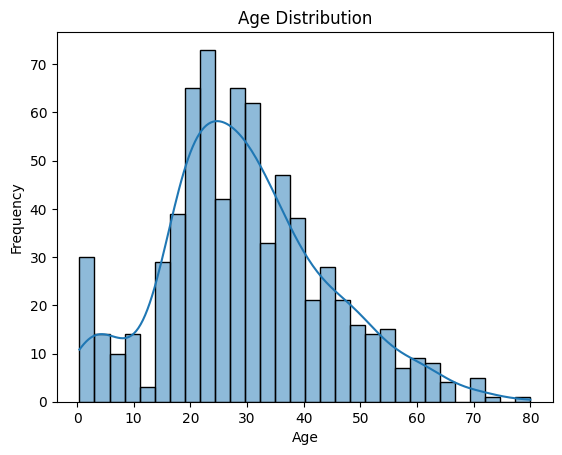

In [48]:
# A histogram is drawn for age to see whether the density is young or old.
plt.figure()
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

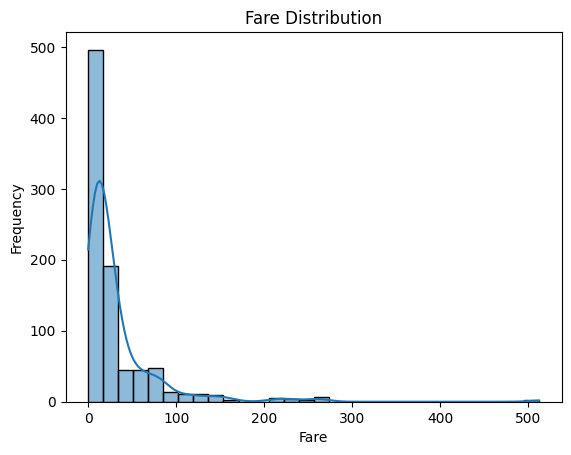

In [49]:
# A histogram is drawn to show ticket price distribution. We can see whether prices are too high.
plt.figure()
sns.histplot(df["Fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()


##### Comments for histograms

###### Age Histogram

####### When the histogram is examined, it is seen that the age range of the passengers is concentrated among young adults. The highest incidence is seen in the 20-35 age range. The frequency decreases as we move into older ages.

###### Fare Histogram
####### An examination of the fare histogram reveals a significantly right-skewed distribution of ticket prices. The vast majority of passengers travel on low-cost tickets. However, a small number of passengers paid very high fares, creating outliers.

##### Variable Types and Probability Analysis

###### Overall Probability of Survival

In [51]:
# Overall survival rate
p_survived = df["Survived"].mean()
p_survived

np.float64(0.3838383838383838)

###### Conditional Probability by Gender

In [53]:
# Survival rate by sex
# Female survival rate
p_female_survived = df[df["Sex"] == "female"]["Survived"].mean()
p_female_survived



np.float64(0.7420382165605095)

In [54]:
# Male survival rate
p_male_survived = df[df["Sex"] == "male"]["Survived"].mean()
p_male_survived

np.float64(0.18890814558058924)

###### Survival probabilities by class


In [72]:
#Survival probabilities according to classes have been examined
pclass_probs = df.groupby("Pclass")["Survived"].mean()
pclass_probs

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

#### Machine Learning

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

##### Independent variables were selected by entering them into the machine learning model. These variables are "Age", "Fare", "Pclass", and "Sex". The model will predict survival by looking at these variables.

In [112]:
features = ["Age", "Fare", "Pclass", "Sex"]
df_ml = df[features + ["Survived"]]
df_ml.head()

,Age,Fare,Pclass,Sex,Survived
0,22.0,7.2500,3,male,0
1,38.0,71.2833,1,female,1
2,26.0,7.9250,3,female,1
3,35.0,53.1000,1,female,1
4,35.0,8.0500,3,male,0


##### Machine learning models cannot work with string data, so they were given numerical values.

In [126]:
df_ml = df[features + ["Survived"]].copy()

df_ml.loc[:, "Sex"] = df_ml["Sex"].map({"male": 0, "female": 1})


# Machine learning models cannot work with null values, so the average age was used for null age values.

In [127]:
df_ml["Age"] = df_ml["Age"].fillna(df_ml["Age"].mean())


In [128]:
# The features that the model will use when deciding whether to survive are specified. 0 means not survived, 1 means survived.
X = df_ml.drop("Survived", axis=1)
y = df_ml["Survived"]


In [129]:
# The dataset was split into two parts. X_train and y_train variables were used to train the model. X_test and y_test variables were used to test the trained model.
# With test_size=0.2, 80% of the model is trained and 20% is tested. In other words, the model predicts the result.
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [130]:
# A Logistic Regression machine learning model was created and the model was trained with 1000 iterations with the max_iter=1000 variable
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [131]:
# The trained model is given X_test data that it has never seen before and is expected to predict.
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 1])

In [132]:
# The accuracy rate of the model's predictions was calculated
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7988826815642458

In [133]:
# The predictions made by the model were compared with the actual results and a 2x2 confusion matrix was created.
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[89, 16],
       [20, 54]])

In [134]:
# A performance report was produced showing detailed metrics showing how well the model predicted each class. This shows which classes it predicted well and which classes it predicted poorly.
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
# Two different probabilities were generated for each test passenger. P(0) means not surviving, and P(1) means surviving.
y_prob = model.predict_proba(X_test)
y_prob[:10]

array([[0.90098559, 0.09901441],
       [0.77740212, 0.22259788],
       [0.8774747 , 0.1225253 ],
       [0.1324554 , 0.8675446 ],
       [0.34224802, 0.65775198],
       [0.08184102, 0.91815898],
       [0.43834696, 0.56165304],
       [0.86468885, 0.13531115],
       [0.35477529, 0.64522471],
       [0.07339554, 0.92660446]])

In [136]:
# The coefficients learned by the model were converted into a table showing the impact of each variable. Here, (+) values ​​increase survival, while (-) values ​​decrease it.
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0]
})
coefficients

,Variable,Coefficient
0,Age,-0.025567
1,Fare,0.001158
2,Pclass,-0.996390
3,Sex,2.464781
